In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from itertools import combinations

In [31]:
df = pd.read_csv("job_salary_prediction_dataset.csv")
num_columns = df.select_dtypes(include="number")
print("First 5 rows:")
display(df.head())

print("\nInfo:")
df.info()

print("\nDescribe:")
display(df.describe(include="all"))

print("\nMissing values:")
display(df.isnull().sum())

df = df.dropna().copy()

First 5 rows:


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB

Describe:


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
count,250000,250000.000000,250000,250000.000000,250000,250000,250000,250000,250000.000000,250000.000000
unique,12,NaN,5,NaN,10,5,10,3,NaN,NaN
top,Backend Developer,NaN,Master,NaN,Finance,Large,Australia,No,NaN,NaN
freq,21125,NaN,50352,NaN,25393,50254,25258,83621,NaN,NaN
mean,NaN,10.005408,NaN,9.997812,NaN,NaN,NaN,NaN,2.491928,145718.080524
std,NaN,6.060602,NaN,5.479288,NaN,NaN,NaN,NaN,1.706475,37407.952729
min,NaN,0.000000,NaN,1.000000,NaN,NaN,NaN,NaN,0.000000,31867.000000
25%,NaN,5.000000,NaN,5.000000,NaN,NaN,NaN,NaN,1.000000,119358.000000
50%,NaN,10.000000,NaN,10.000000,NaN,NaN,NaN,NaN,2.000000,143453.000000
75%,NaN,15.000000,NaN,15.000000,NaN,NaN,NaN,NaN,4.000000,169492.000000



Missing values:


job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [32]:
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
pearson_corr = df[numeric_cols].corr(method="pearson")
spearman_corr = df[numeric_cols].corr(method="spearman")
results = []
for col1, col2 in combinations(numeric_cols, 2):
    pair_data = df[[col1, col2]].dropna()
    
    pearson_r, pearson_p = pearsonr(pair_data[col1], pair_data[col2])
    spearman_rho, spearman_p = spearmanr(pair_data[col1], pair_data[col2])
    
    results.append({
        "Feature 1": col1,
        "Feature 2": col2,
        "Pearson r": pearson_r,
        "Pearson p-value": pearson_p,
        "Spearman rho": spearman_rho,
        "Spearman p-value": spearman_p,
        "Absolute Pearson r": abs(pearson_r),
        "Absolute Spearman rho": abs(spearman_rho)
    })

summary_table = pd.DataFrame(results)

summary_table = summary_table.sort_values(by="Absolute Pearson r", ascending=False).reset_index(drop=True)
summary_table

,Feature 1,Feature 2,Pearson r,Pearson p-value,Spearman rho,Spearman p-value,Absolute Pearson r,Absolute Spearman rho
0,experience_years,salary,0.437627,0.000000e+00,0.437891,0.000000e+00,0.437627,0.437891
1,skills_count,salary,0.127300,0.000000e+00,0.125180,0.000000e+00,0.127300,0.125180
2,certifications,salary,0.073819,5.080830e-299,0.071958,3.323454e-284,0.073819,0.071958
3,skills_count,certifications,-0.002230,2.649292e-01,-0.002227,2.655564e-01,0.002230,0.002227
4,experience_years,certifications,-0.000198,9.211162e-01,-0.000197,9.216315e-01,0.000198,0.000197
5,experience_years,skills_count,0.000149,9.406620e-01,0.000146,9.417860e-01,0.000149,0.000146


### Task 1 Interpretation

The pair **experience_years and salary** shows the strongest linear relationship, with a **Pearson correlation of 0.4376**. This indicates a **moderate positive linear association**, meaning that as experience increases, salary also tends to increase. 

The pairs **skills_count and salary** (**r = 0.1273**) and **certifications and salary** (**r = 0.0738**) also show positive relationships, but these are **much weaker**. The other pairs have correlations extremely close to zero, which suggests little to no linear relationship between them.

There is **no noticeable disagreement** between Pearson and Spearman for any pair in this dataset. Their values are almost identical in all cases, which suggests that the relationships are either approximately linear or consistently monotonic, and that there are no major outliers or strong non-linear patterns affecting the results.

If Pearson and Spearman had differed a lot, this could have been caused by **outliers**, a **non-linear but monotonic relationship**, or unusual subgroup patterns in the data.

<Axes: >

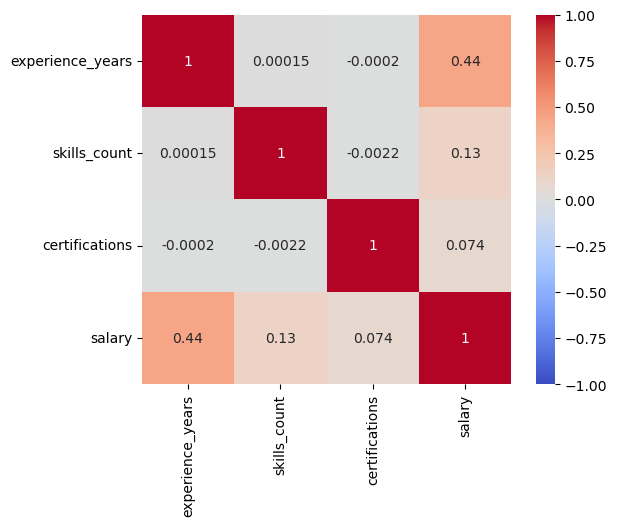

In [33]:
# Task 2.1

corr_matrix = pearson_corr.copy()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True)

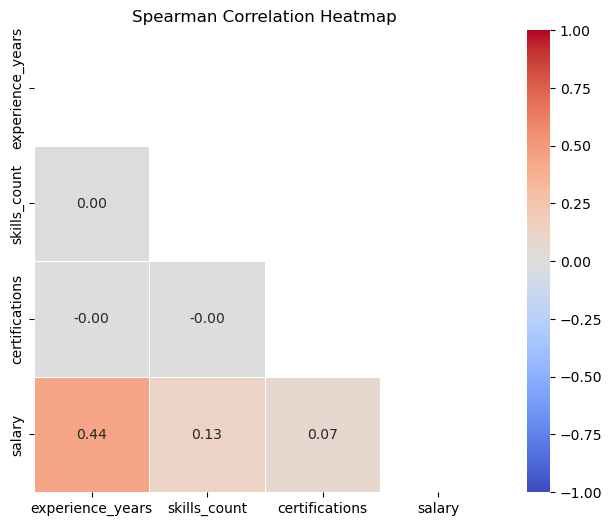

In [34]:
spearman_corr_matrix = spearman_corr.copy()

mask = np.triu(np.ones_like(spearman_corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(
    spearman_corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title("Spearman Correlation Heatmap")
plt.show()

### Task 2 Interpretation

The Pearson and Spearman heatmaps agree on the main pattern in the data. In both heatmaps, the strongest positive relationship is between **experience_years** and **salary**, while **skills_count** and **salary** show a weak positive relationship, and **certifications** and **salary** show a very weak positive relationship. The relationships among **experience_years**, **skills_count**, and **certifications** are all very close to zero in both heatmaps.

The two heatmaps differ only slightly in the exact correlation values, but these differences are very small and not meaningful in practice. This tells us that the relationships in the dataset have a similar linear and monotonic structure. In other words, there is no strong sign of a curved monotonic relationship, major outliers, or unusual rank-based behavior affecting the results.

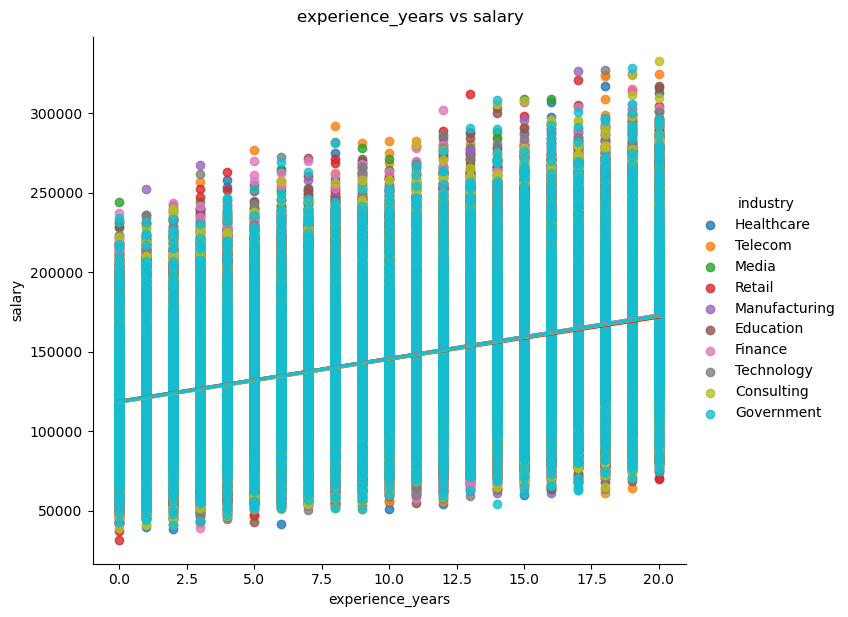

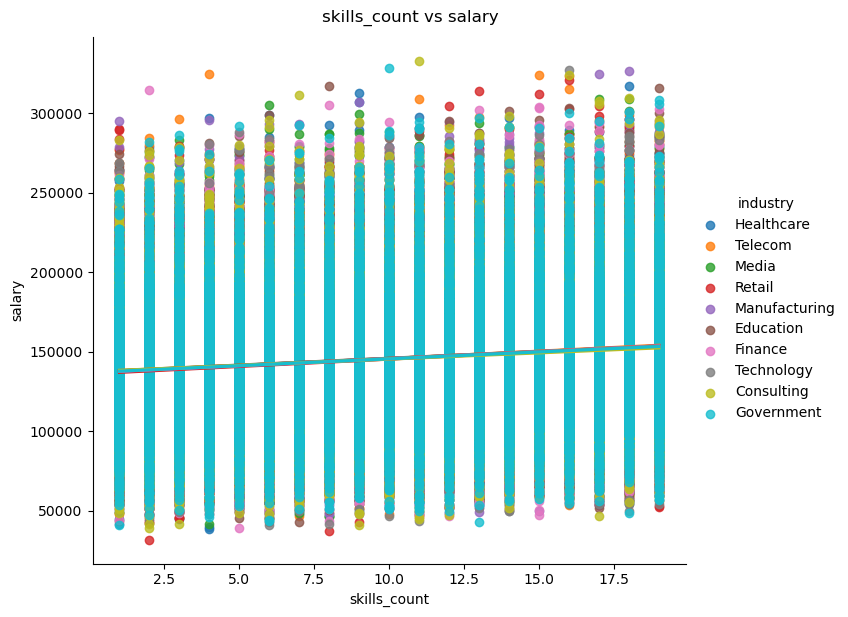

In [ ]:
# TASK 3

import seaborn as sns
import matplotlib.pyplot as plt

group_col = "industry"
top_3_pairs = [
    ("experience_years", "salary"),
    ("skills_count", "salary"),
    ("certifications", "salary")
]

for x_col, y_col in top_3_pairs:
    g = sns.lmplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=group_col,
        height=6,
        aspect=1.2
    )
    g.fig.suptitle(f"{x_col} vs {y_col}", y=1.02)
    plt.show()

### Task 3 Interpretation

For **experience_years vs salary**, the regression line captures the overall pattern reasonably well because the relationship is clearly positive: as experience increases, salary generally increases too. However, the points are widely spread around the line, which means experience is important but does not explain salary perfectly by itself.

For **skills_count vs salary** and **certifications vs salary**, the regression lines are much flatter, so they capture only a weak positive trend. In these two pairs, the line does not explain the pattern as strongly, because the data are more scattered and the relationships are much weaker.

The subgroups appear to have **different intercepts** more clearly than different slopes. This means some groups tend to have generally higher or lower salary levels overall, even if the direction of the relationship stays similar. There is no strong visual evidence of major slope differences between groups, but the vertical separation suggests that group membership may affect the baseline salary level.